랜덤포레스트(Random Forest)는 결정의사트리(Decision Tree)를 기본 모델로 사용하는 배깅(Bagging) 방식의 앙상블 모델 입니다.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

make_regression 함수는 scikit-learn의 datasets 모듈에서 제공하는 함수로, 회귀(regression) 문제를 위한 합성 데이터를 생성합니다. 

n_samples=100 생성할 샘플(데이터 포인트)의 수를 지정하며, 100개의 샘플(행)이 생성됩니다.

n_features=5 각 샘플이 가지는 피처(특성)의 수를 의미합니다. 각 샘플은 5개의 피처(열)로 구성됩니다.

noise=0.1 출력 값에 추가되는 가우시안 노이즈(잡음)의 표준편차를 지정합니다. 0.1의 작은 노이즈가 추가되어, 실제 선형 관계에 약간의 무작위 변동성이 포함됩니다. 이로 인해 모델이 약간의 불확실성이나 오차를 갖게 되어 현실적인 데이터를 시뮬레이션합니다.

random_state=42 무작위 데이터 생성 과정에 대한 시드(seed)를 고정합니다.은 시드를 사용하면 데이터 생성 결과가 매번 동일하게 재현(reproducible)되므로, 실험 결과의 일관성을 유지할 수 있습니다.


In [2]:
# 데이터 생성
X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)


 X (특성 행렬, Feature Matrix)와 y (타깃 벡터, Target Vector)를 반환하며, 이 데이터를 사용해 회귀 모델의 학습 및 평가에 활용할 수 있습니다.
 X는 각 샘플의 입력 데이터
 y는 각 샘플에 대한 정답(레이블 또는 회귀 값)
 X.shape = n_samples * n_features

In [8]:
X.shape
X

array([[ 0.97511973, -0.67716171, -0.01224677, -0.89725437,  0.07580456],
       [ 0.08187414, -0.48536355,  0.75896922, -0.77282521, -0.23681861],
       [-1.4123037 , -0.90802408, -0.56228753, -1.01283112,  0.31424733],
       [-0.64511975,  0.36163603,  1.35624003, -0.07201012,  1.0035329 ],
       [-0.62269952,  0.28099187, -1.9520878 , -0.1517851 ,  0.58831721],
       [-0.45006547,  0.04698059, -1.59442766, -0.59937502,  0.0052437 ],
       [ 0.77463405,  0.44381943, -0.48423407,  1.26691115, -0.70766947],
       [ 0.35701549,  0.8496021 , -0.20812225, -0.49300093, -0.58936476],
       [-1.3044695 , -0.08912004,  0.38406545, -0.03269475, -2.0674421 ],
       [ 0.17318093, -1.24573878, -0.44651495,  0.85639879,  0.21409374],
       [ 0.29698467,  0.52194157,  0.78182287, -1.23695071, -1.32045661],
       [-1.72491783, -1.91328024, -0.46341769, -0.46572975,  0.24196227],
       [-1.98756891,  0.09176078,  0.8219025 ,  0.08704707, -0.29900735],
       [-0.0555477 , -1.70338244,  0.0

In [ ]:

y.shape

(100,)

X[:, 0]는 0부터 99번째 행과 0번째 열에 해당하는 값들을 모은 1차원 배열

In [7]:
X[:, 0]

array([ 0.97511973,  0.08187414, -1.4123037 , -0.64511975, -0.62269952,
       -0.45006547,  0.77463405,  0.35701549, -1.3044695 ,  0.17318093,
        0.29698467, -1.72491783, -1.98756891, -0.0555477 ,  0.65655361,
       -0.01901621, -0.39210815,  0.19686124, -1.23086432,  1.50235705,
        1.52312408,  0.96337613, -1.20029641, -0.57690366, -1.00601738,
        3.85273149, -0.3853136 , -0.07444592, -1.38279973,  2.15318246,
       -0.47193187, -0.13014305,  1.23781631,  1.64496771,  0.06751848,
        0.85243333,  0.75193303, -0.8084936 ,  0.40498171, -0.75373616,
       -0.91942423,  0.51326743,  0.82254491,  0.54256004,  1.11957491,
        1.17944012,  0.64537595,  0.58685709,  0.2766908 ,  0.69014399,
       -0.50347565, -1.76304016, -0.02090159, -0.25256815, -0.75913266,
       -1.19787789, -1.75873949, -2.6197451 , -0.75635075,  0.33231401,
       -0.98150865,  0.62834551,  1.30547881, -0.21344715,  2.13303337,
        0.13074058,  2.72016917, -0.16128571, -0.53025762, -0.23

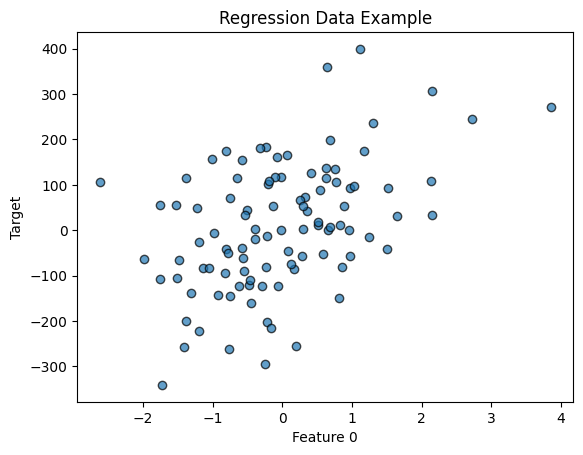

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], y, edgecolor='k', alpha=0.7)
plt.xlabel("Feature 0")
plt.ylabel("Target")
plt.title("Regression Data Example")
plt.show()

RandomForestRegressor는 각 트리의 예측값의 평균을 계산하여 최종 예측값을 산출합니다.

n_estimators=100 100개의 개별 결정 트리 모델이 만들어집니다.
max_depth=5 각 트리의 최대 깊이를 5로 제한한다는 의미입니다.
min_samples_split=30 각 분할 시 최소 샘플 수를 요구하여, 데이터가 부족할 경우 분할을 중지시킵니다.

min_samples_leaf=15 학습 과정에서 각 leaf node(최종 예측 노드)에 최소 15개의 샘플이 포함되어야 한다는 조건 입니다. 
이 설정은 트리가 너무 작은 데이터 조각으로 분할되어 훈련 데이터에 과도하게 맞춰지는 과적합(overfitting)이 되는 것을 방지하는 규제(regularization) 역할을 하며, 작은 데이터 조각에 포함된 노이즈나 특수 사례의 데이터까지 학습함으로써 새로운 데이터에 대한 일반화(generalization) 가 어려워지는 것을 방지합니다. 

루트 노드(Root Node)란? 트리의 시작점으로, 전체 데이터를 포함합니다.
내부 노드(Internal Node)란? 데이터를 특정 기준으로 분할하여 여러 하위 노드로 나누는 중간 단계입니다. 
리프 노드(Leaf Node)란? 분기가 끝나고 더 이상 분할되지 않는 노드로, 이곳에서 최종 예측 결과(회귀값)가 산출됩니다.


In [ ]:

# 모델 학습
model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=30, min_samples_leaf=15, random_state=42)
model.fit(X, y)

RandomForestRegressor(max_depth=5, min_samples_leaf=15, min_samples_split=30,
                      random_state=42)

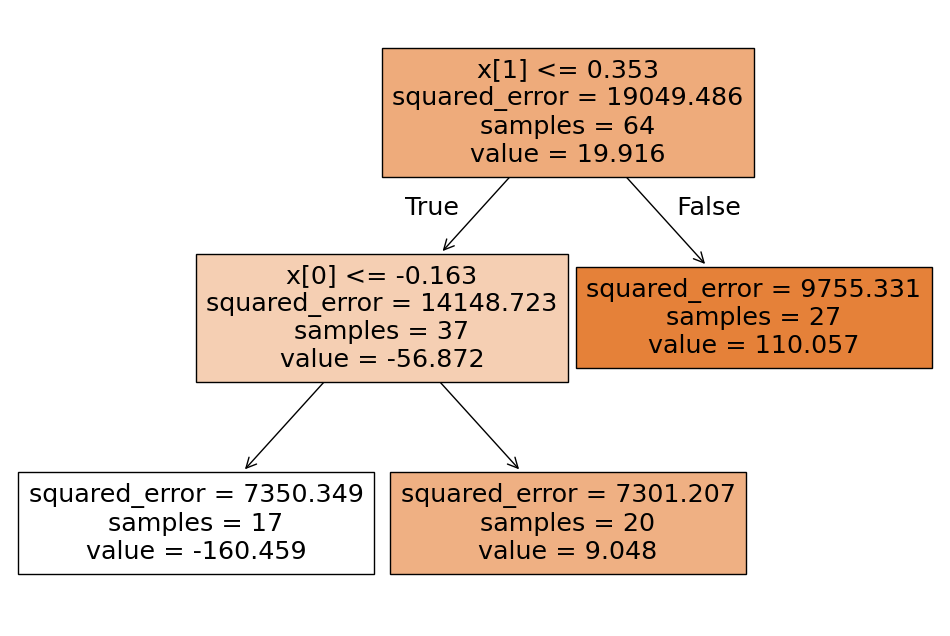

In [3]:
# 첫 번째 트리 시각화
estimator = model.estimators_[0]

plt.figure(figsize=(12, 8))
plot_tree(estimator, filled=True)
plt.show()